In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
import pymc as pm
import pymc_bart as pmb
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from eICUUtil import *


/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [3]:
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'DeathAtDischarge', 
                                                                         aTreatmentColumn = 'treatment_hypothermia', aDropColumns=['Hypothermia', 'both_hypothermia'], aSkipTemp = True) 

/home/idies/workspace/Storage/hkim171/ACCM_PMAP_SEPSIS/mbranda1/ttmhte/eICU/eICUUtil.py:6: DtypeWarning: Columns (2058,2069,2080,2082,2083,2088,2094,2098,2255,2257) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [5]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [6]:

with pm.Model() as model:
    X_shared = pm.MutableData('X_shared', X_train_transf)
    y_shared = pm.MutableData('y_shared', y_train)
    u = pmb.BART('u', X = X_shared, Y= y_train, m=30)
    p = 1 / (1 + np.exp(-u))
    y_obs= pm.Bernoulli('y_obs', p=p, observed = y_shared)
    trace = pm.sample(50, return_inferencedata=True)
    # trace = az.from_netcdf('bart_model_tracedc.nc')
# Save trace 
# az.to_netcdf(trace, 'bart_model_tracedc.nc')

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Multiprocess sampling (4 chains in 4 jobs)
PGBART: [u]


Sampling 4 chains for 1_000 tune and 50 draw iterations (4_000 + 200 draws total) took 39 seconds.
The number of samples is too small to check convergence reliably.


In [7]:
import arviz as az
az.to_netcdf(trace, 'bart_model_tracedc.nc')

'bart_model_tracedc.nc'

In [9]:
with model:
    pm.set_data({'X_shared': X_train_transf, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    # Calculate the mean predicted probability
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_train, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_train, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [y_obs]


ROC AUC: 0.78
Accuracy: 0.72


In [28]:
with model:
    pm.set_data({'X_shared': X_test_transf, 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [u, y_obs]


ROC AUC: 0.76
Accuracy: 0.69


In [10]:
myXValueModified1 = X_train.copy()
myXValueModified1['Hypothermia'] = 1.0
myXValueModified2 = X_train.copy()
myXValueModified2['Hypothermia'] = 0.0
with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified1), 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified2), 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data



Sampling: [y_obs]


Sampling: [y_obs]


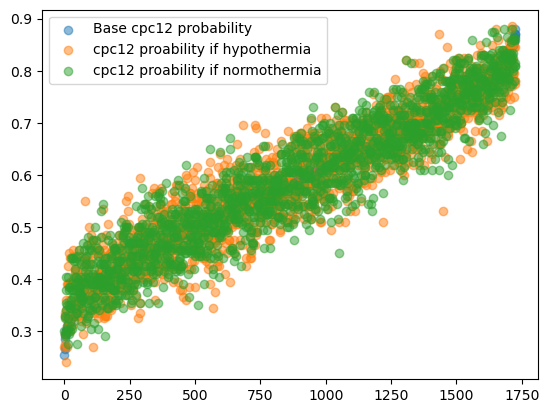

In [11]:
myYPred =  (predicted_probs1 - predicted_probs2)
myYPred = predicted_probs
myDfPreds = pd.DataFrame()
myDfPreds['base'] = predicted_probs
myDfPreds['group1'] = predicted_probs1
myDfPreds['group2'] = predicted_probs2
myDfPreds.sort_values(by=['base'], inplace=True)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['base'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group1'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group2'], alpha = 0.5)
plt.legend(['Base cpc12 probability', 'cpc12 proability if hypothermia', 'cpc12 proability if normothermia'])


In [23]:
myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = myYPred

In [24]:
myNewDf

,predicted_effect
0,0.490
1,0.615
2,0.625
3,0.655
4,0.545
...,...
1721,0.450
1722,0.750
1723,0.555
1724,0.400


Optimization terminated successfully.
         Current function value: 0.677273
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.677190
         Iterations 4
Likelihood ratio of test results:
Chi square statistic: 0.2869728152704738
p-value: 0.8663325756155904
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                 1726
Model:                          Logit   Df Residuals:                     1722
Method:                           MLE   Df Model:                            3
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                0.002202
Time:                        17:58:40   Log-Likelihood:                -1169.0
converged:                       True   LL-Null:                       -1171.6
Covariance Type:            nonrobust   LLR p-value:                    0.1604
                      

0.8663325756155904

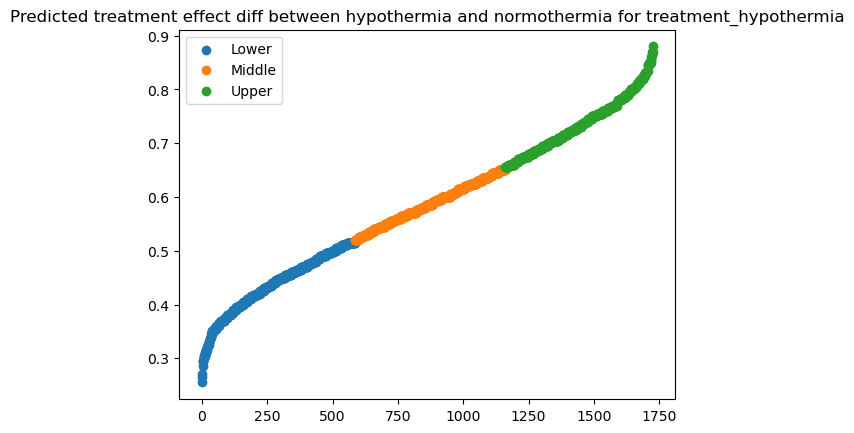

In [26]:
low_third, upper_third, myNewDf = plotPredictedTreatmentEffect(myNewDf, 'treatment_hypothermia')
getTreatmentEffectDiffDataFrame(X_train_transf, y_train, myNewDf, 'DeathAtDischarge', 'bin__treatment_hypothermia', True)

In [35]:
myData = pd.concat([X_train['Hypothermia'].reset_index(), myNewDf['predicted_effect_group'].reset_index(), y_train.reset_index()], axis=1)


In [39]:
myData.groupby(['Hypothermia', 'predicted_effect_group']).agg({'LastMGCSPositive': 'sum'})

LastMGCSPositive
Hypothermia predicted_effect_group                  
0           Lower                                215
            Middle                               192
            Upper                                195
1           Lower                                 35
            Middle                                40
            Upper                                 37